In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = os.environ.get('KAGGLE_API_TOKEN', '')  # set this in your shell/.env, never hardcode

import kagglehub
path = kagglehub.dataset_download("asaniczka/data-analyst-job-postings")

print("Dataset downloaded to:", path)
print("Files inside:", os.listdir(path))

Dataset downloaded to: C:\Users\A\.cache\kagglehub\datasets\asaniczka\data-analyst-job-postings\versions\101
Files inside: ['postings.csv']


In [3]:
import pandas as pd

# Build the full path to the CSV using the path variable from the previous cell
csv_path = os.path.join(path, "postings.csv")

df = pd.read_csv(csv_path)

# Basic data inventory
print("Shape (rows, columns):", df.shape)
print("\nColumn names and types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nFirst 3 rows:")
df.head(3)

Shape (rows, columns): (12894, 11)

Column names and types:
job_title         str
company           str
job_location      str
job_link          str
first_seen        str
search_city       str
search_country    str
job level         str
job_type          str
job_summary       str
job_skills        str
dtype: object

Missing values per column:
job_title           0
company             0
job_location        0
job_link            0
first_seen          0
search_city         0
search_country      0
job level           0
job_type            0
job_summary        43
job_skills        189
dtype: int64

First 3 rows:


,job_title,company,job_location,job_link,first_seen,search_city,search_country,job level,job_type,job_summary,job_skills
0,"Data Analyst-SQL, Tableau",Zortech Solutions,"Mountain View, CA",https://www.linkedin.com/jobs/data-analyst-jobs,2023-12-20,Bloomington,United States,Associate,Onsite,NaN,NaN
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-rese...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer ...,"Data analysis, Market research, Survey develop..."
2,Business Systems Analyst `1,Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/business-sy...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Overview\nThe Business Systems Analyst 1 perfo...,"Business Analysis, Technical Writing, Software..."


In [4]:
# Check country/city distribution
# Check country/city distribution
print("Top countries:")
print(df['search_country'].value_counts())

print("\nTop 10 cities:")
print(df['search_city'].value_counts().head(10))

print("\nJob level distribution:")
print(df['job level'].value_counts())   # <-- fixed: space, not underscore

# Look at a few full (non-truncated) job_skills values
print("\nSample job_skills values (full text):")
for skill_text in df['job_skills'].dropna().head(5):
    print("-", skill_text)
    print()

Top countries:
search_country
United States     10386
United Kingdom     1187
Canada              876
Australia           445
Name: count, dtype: int64

Top 10 cities:
search_city
Hollywood          150
Beverly            115
Atlanta            114
Pasadena           112
Garland            105
Eastchester        104
Montpelier         103
New South Wales    101
Alexandria          99
Greater London      97
Name: count, dtype: int64

Job level distribution:
job level
Mid senior    9691
Associate     3203
Name: count, dtype: int64

Sample job_skills values (full text):
- Data analysis, Market research, Survey development, Analytical methods, Quantitative initiatives, Qualitative initiatives, Business solutions, Project management, Communication skills, Customer service, Statistical analysis, Data visualization, Data storytelling, Stakeholder engagement, Windows, Excel, Word, PowerPoint, Market research software, Marketing, Analytics, Psychology, Data science

- Business Analysis, Technic

In [5]:
# Full job level breakdown
print("Full job level distribution:")
print(df['job level'].value_counts())

print("\nFull job type distribution:")
print(df['job_type'].value_counts())

# Check how many unique 'skills' exist once we split on commas
all_skills_raw = df['job_skills'].dropna().str.split(',')
flat_skills = [skill.strip() for sublist in all_skills_raw for skill in sublist]

print(f"\nTotal skill mentions (not unique): {len(flat_skills)}")
print(f"Unique skill phrases: {len(set(flat_skills))}")

# Show the 30 most common ones to eyeball quality/consistency
from collections import Counter
top_skills = Counter(flat_skills).most_common(30)
print("\nTop 30 most common skill phrases:")
for skill, count in top_skills:
    print(f"{skill}: {count}")

Full job level distribution:
job level
Mid senior    9691
Associate     3203
Name: count, dtype: int64

Full job type distribution:
job_type
Onsite    6670
Hybrid    4339
Remote    1885
Name: count, dtype: int64

Total skill mentions (not unique): 228841
Unique skill phrases: 53268

Top 30 most common skill phrases:
SQL: 4286
Data Analysis: 2828
Communication: 2466
Tableau: 2153
Excel: 2150
Python: 2132
Data analysis: 1819
Power BI: 1741
Project Management: 1588
Reporting: 1389
Data Visualization: 1389
Business Analysis: 1217
R: 1211
Problem Solving: 981
Teamwork: 976
Agile: 944
Project management: 930
Microsoft Excel: 923
Data visualization: 907
Microsoft Office Suite: 884
Business Intelligence: 869
Accounting: 835
Data Analytics: 830
Collaboration: 822
PowerPoint: 796
Finance: 750
Statistics: 707
Microsoft Office: 703
Forecasting: 686
Communication skills: 642


In [6]:
import re

def clean_skill(skill):
    """
    Standardize a skill phrase:
    - lowercase everything
    - strip leading/trailing whitespace
    - collapse multiple spaces into one
    - remove trailing 'skills' or 'skill' (e.g. 'communication skills' -> 'communication')
    """
    skill = skill.strip().lower()
    skill = re.sub(r'\s+', ' ', skill)
    skill = re.sub(r'\s+skills?$', '', skill)  # drop trailing "skill"/"skills"
    return skill

# Re-split and clean every skill phrase
all_skills_raw = df['job_skills'].dropna().str.split(',')
flat_skills_cleaned = [clean_skill(skill) for sublist in all_skills_raw for skill in sublist]

print(f"Total skill mentions: {len(flat_skills_cleaned)}")
print(f"Unique skill phrases after cleaning: {len(set(flat_skills_cleaned))}")

from collections import Counter
top_skills_cleaned = Counter(flat_skills_cleaned).most_common(30)
print("\nTop 30 skills after cleaning:")
for skill, count in top_skills_cleaned:
    print(f"{skill}: {count}")

Total skill mentions: 228841
Unique skill phrases after cleaning: 46340

Top 30 skills after cleaning:
data analysis: 4692
sql: 4289
communication: 3688
project management: 2564
data visualization: 2328
tableau: 2168
excel: 2157
python: 2144
power bi: 1749
business analysis: 1623
reporting: 1401
problem solving: 1388
problemsolving: 1268
business intelligence: 1246
r: 1218
analytical: 1197
data analytics: 1164
teamwork: 1025
data management: 1011
data mining: 952
agile: 951
microsoft excel: 924
microsoft office suite: 918
collaboration: 869
data modeling: 846
accounting: 838
powerpoint: 831
presentation: 784
attention to detail: 782
financial analysis: 767


In [7]:
import re

# Curated list of common Data Analyst skills to track explicitly.
# Each entry maps a "clean" skill name -> list of phrase variants that should count as a match.
# This handles spacing/naming inconsistencies (e.g. "problem solving" vs "problemsolving")
# without trying to auto-merge the entire messy long tail.
skill_variants = {
    'sql': ['sql'],
    'python': ['python'],
    'excel': ['excel', 'microsoft excel', 'ms excel'],
    'tableau': ['tableau'],
    'power bi': ['power bi', 'powerbi'],
    'r': ['r programming', ' r ', 'r,'],  # handled carefully below, see note
    'statistics': ['statistics', 'statistical analysis'],
    'data analysis': ['data analysis', 'data analytics'],
    'data visualization': ['data visualization', 'data viz'],
    'business intelligence': ['business intelligence', 'bi tools'],
    'communication': ['communication'],
    'problem solving': ['problem solving', 'problemsolving'],
    'project management': ['project management'],
    'business analysis': ['business analysis'],
    'data mining': ['data mining'],
    'machine learning': ['machine learning', 'ml'],
    'a/b testing': ['a/b testing', 'ab testing'],
    'aws': ['aws', 'amazon web services'],
    'azure': ['azure'],
    'google cloud': ['google cloud', 'gcp'],
    'dbt': ['dbt'],
    'genai': ['genai', 'generative ai', 'chatgpt', 'llm'],
    'powerpoint': ['powerpoint', 'ms powerpoint'],
    'sas': [' sas ', 'sas,', 'sas.'],
    'looker': ['looker'],
    'spss': ['spss'],
}

# Use the cleaned, comma-joined skills string (lowercased) per row for matching.
# We rebuild a per-row cleaned string rather than the flat list, since we need
# to match within each posting individually, not across the whole dataset.
def clean_skills_string(raw):
    if pd.isna(raw):
        return ""
    parts = [clean_skill(p) for p in raw.split(',')]
    return " , ".join(parts)  # padded commas help with the ' r ' style matching above

df['job_skills_clean'] = df['job_skills'].apply(clean_skills_string)

# Create one boolean column per curated skill
for skill_name, variants in skill_variants.items():
    col_name = f"skill_{skill_name.replace(' ', '_').replace('/', '_')}"
    df[col_name] = df['job_skills_clean'].apply(
        lambda text: any(variant in text for variant in variants)
    )

# Quick sanity check: how many postings mention each curated skill
skill_cols = [c for c in df.columns if c.startswith('skill_')]
skill_counts = df[skill_cols].sum().sort_values(ascending=False)
print("Postings mentioning each curated skill (out of", len(df), "total postings):")
print(skill_counts)

Postings mentioning each curated skill (out of 12894 total postings):
skill_data_analysis            5797
skill_sql                      4844
skill_communication            4542
skill_excel                    3800
skill_problem_solving          2744
skill_project_management       2705
skill_power_bi                 2411
skill_data_visualization       2386
skill_python                   2213
skill_tableau                  2194
skill_business_analysis        1686
skill_business_intelligence    1543
skill_statistics               1402
skill_powerpoint               1266
skill_r                        1265
skill_machine_learning         1248
skill_data_mining               949
skill_azure                     829
skill_aws                       520
skill_sas                       486
skill_a_b_testing               240
skill_looker                    210
skill_google_cloud              179
skill_spss                      170
skill_genai                      95
skill_dbt                     

In [8]:
# Download the second dataset (salary-focused)
path2 = kagglehub.dataset_download("mohankrishnathalla/global-ai-and-data-jobs-salary-dataset")

print("Dataset downloaded to:", path2)
print("Files inside:", os.listdir(path2))

Dataset downloaded to: C:\Users\A\.cache\kagglehub\datasets\mohankrishnathalla\global-ai-and-data-jobs-salary-dataset\versions\1
Files inside: ['global_ai_jobs.csv']


In [9]:
import pandas as pd

# Adjust filename once we see what's actually inside path2
csv_path2 = os.path.join(path2, os.listdir(path2)[0])  # grabs the first file found

df2 = pd.read_csv(csv_path2)

print("Shape (rows, columns):", df2.shape)
print("\nColumn names and types:")
print(df2.dtypes)
print("\nMissing values per column:")
print(df2.isnull().sum())
print("\nFirst 5 rows:")
df2.head(5)

Shape (rows, columns): (90000, 35)

Column names and types:
id                           int64
country                        str
job_role                       str
ai_specialization              str
experience_level               str
experience_years             int64
salary_usd                   int64
bonus_usd                    int64
education_required             str
industry                       str
company_size                   str
interview_rounds             int64
year                         int64
work_mode                      str
weekly_hours               float64
company_rating             float64
job_openings                 int64
hiring_difficulty_score    float64
layoff_risk                float64
ai_adoption_score            int64
company_funding_billion    float64
economic_index             float64
ai_maturity_years            int64
offer_acceptance_rate      float64
tax_rate_percent           float64
vacation_days                int64
skill_demand_score           i

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


In [10]:
print("Unique job roles in this dataset:")
print(df2['job_role'].value_counts())

Unique job roles in this dataset:
job_role
NLP Engineer                 11412
Software Engineer AI         11333
Research Scientist           11309
Machine Learning Engineer    11263
AI Engineer                  11247
Computer Vision Engineer     11227
Data Scientist               11146
Data Analyst                 11063
Name: count, dtype: int64


In [11]:
# Filter to just Data Analyst rows
df2_da = df2[df2['job_role'] == 'Data Analyst'].copy()

print("Data Analyst subset shape:", df2_da.shape)

print("\nExperience level distribution:")
print(df2_da['experience_level'].value_counts())

print("\nTop countries:")
print(df2_da['country'].value_counts())

print("\nSalary (USD) summary stats:")
print(df2_da['salary_usd'].describe())

Data Analyst subset shape: (11063, 35)

Experience level distribution:
experience_level
Mid       2831
Entry     2767
Senior    2763
Lead      2702
Name: count, dtype: int64

Top countries:
country
Japan          981
France         963
Canada         949
Germany        928
Netherlands    927
Australia      911
UAE            910
UK             908
Brazil         907
USA            904
India          898
Singapore      877
Name: count, dtype: int64

Salary (USD) summary stats:
count     11063.000000
mean      69429.268914
std       29706.668773
min       28000.000000
25%       47085.000000
50%       62657.000000
75%       88751.000000
max      187484.000000
Name: salary_usd, dtype: float64


In [12]:
# Full salary breakdown by experience level
print("Salary (USD) by experience level:")
print(df2_da.groupby('experience_level')['salary_usd'].agg(['mean', 'median', 'min', 'max', 'count']))

# Full salary breakdown by country (sorted by median salary)
print("\nSalary (USD) by country:")
print(df2_da.groupby('country')['salary_usd'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False))

# Specifically pull out India's numbers for a quick check
print("\nIndia-specific stats:")
print(df2_da[df2_da['country'] == 'India']['salary_usd'].describe())

Salary (USD) by experience level:
                           mean    median    min     max  count
experience_level                                               
Entry              45019.295266   45614.0  28000   75395   2767
Lead              102407.774611  105430.0  31735  187484   2702
Mid                56067.566937   57593.0  28000  100494   2831
Senior             75314.702497   77888.0  28000  138724   2763

Salary (USD) by country:
                     mean   median  count
country                                  
USA          94869.641593  86467.0    904
Singapore    85177.114025  79806.0    877
Australia    78502.000000  72423.0    911
Canada       77392.500527  71965.0    949
UK           74472.183921  67761.0    908
Netherlands  72348.604099  66753.0    927
Germany      71877.718750  66584.0    928
Japan        70123.375127  64176.0    981
UAE          67065.952747  62851.5    910
France       68418.950156  61118.0    963
Brazil       39411.210584  35534.0    907
India     

In [13]:
# Check India's experience-level mix specifically
print("India's experience level distribution:")
print(df2_da[df2_da['country'] == 'India']['experience_level'].value_counts())

# Cross-check: India salary by experience level (compare to global numbers above)
print("\nIndia salary by experience level:")
print(df2_da[df2_da['country'] == 'India'].groupby('experience_level')['salary_usd'].agg(['mean', 'median', 'count']))

India's experience level distribution:
experience_level
Mid       241
Senior    228
Entry     221
Lead      208
Name: count, dtype: int64

India salary by experience level:
                          mean   median  count
experience_level                              
Entry             28000.000000  28000.0    221
Lead              44144.312500  43594.5    208
Mid               28322.248963  28000.0    241
Senior            33474.324561  32968.0    228


In [14]:
# Compare skill prevalence between Associate and Mid senior postings
skill_cols = [c for c in df.columns if c.startswith('skill_')]

comparison = df.groupby('job level')[skill_cols].mean().T
comparison.columns = ['Associate_pct', 'Mid_senior_pct']
comparison = comparison.sort_values('Mid_senior_pct', ascending=False)

print("Skill prevalence by job level (as % of postings, 0.0-1.0 scale):")
print(comparison)

Skill prevalence by job level (as % of postings, 0.0-1.0 scale):
                             Associate_pct  Mid_senior_pct
skill_data_analysis               0.433032        0.455061
skill_sql                         0.355916        0.382210
skill_communication               0.347799        0.353730
skill_excel                       0.329067        0.283356
skill_problem_solving             0.197939        0.217728
skill_project_management          0.210740        0.209473
skill_power_bi                    0.154543        0.197709
skill_data_visualization          0.163597        0.192137
skill_tableau                     0.155167        0.175111
skill_python                      0.162036        0.174801
skill_business_intelligence       0.105526        0.124342
skill_business_analysis           0.166719        0.118873
skill_statistics                  0.080549        0.118048
skill_r                           0.086794        0.101847
skill_machine_learning            0.102404        

In [15]:
import numpy as np

# Build a co-occurrence matrix: for each pair of skills, how many postings mention both?
skill_cols = [c for c in df.columns if c.startswith('skill_')]
skill_matrix = df[skill_cols].astype(int)

# Co-occurrence = matrix multiplication of (skills x postings) with its transpose
cooccurrence = skill_matrix.T.dot(skill_matrix)

# Clean up labels (strip 'skill_' prefix for readability)
clean_labels = [c.replace('skill_', '') for c in skill_cols]
cooccurrence.index = clean_labels
cooccurrence.columns = clean_labels

print("Co-occurrence matrix (number of postings mentioning both skills):")
print(cooccurrence)

Co-occurrence matrix (number of postings mentioning both skills):
                        sql  python  excel  tableau  power_bi     r  \
sql                    4844    1848   1635     1816      1677  1049   
python                 1848    2213    612     1124       845  1124   
excel                  1635     612   3800      917      1125   403   
tableau                1816    1124    917     2194      1209   775   
power_bi               1677     845   1125     1209      2411   573   
r                      1049    1124    403      775       573  1265   
statistics              888     582    538      569       445   442   
data_analysis          2968    1480   2159     1601      1643   955   
data_visualization     1719    1015    873     1234      1067   718   
business_intelligence  1106     539    585      716       651   354   
communication          1524     613   1563      679       776   377   
problem_solving        1043     419    967      478       501   263   
project_man

In [16]:
# Normalize: what % of postings mentioning skill A also mention skill B
# (this reveals genuine pairing strength, not just overall popularity)
cooccurrence_pct = cooccurrence.div(np.diag(cooccurrence), axis=0) * 100

print("Of postings mentioning the ROW skill, % that also mention the COLUMN skill:")
print(cooccurrence_pct.round(1))

# Find the strongest pairings (excluding self-pairs) for a clean summary
pairs = []
for i, row_skill in enumerate(clean_labels):
    for j, col_skill in enumerate(clean_labels):
        if i < j:  # avoid duplicates and self-pairs
            pairs.append((row_skill, col_skill, cooccurrence.iloc[i, j]))

pairs_df = pd.DataFrame(pairs, columns=['skill_a', 'skill_b', 'co_occurring_postings'])
pairs_df = pairs_df.sort_values('co_occurring_postings', ascending=False)

print("\nTop 15 strongest skill pairings (by raw co-occurrence count):")
print(pairs_df.head(15).to_string(index=False))

Of postings mentioning the ROW skill, % that also mention the COLUMN skill:
                         sql  python  excel  tableau  power_bi      r  \
sql                    100.0    38.2   33.8     37.5      34.6   21.7   
python                  83.5   100.0   27.7     50.8      38.2   50.8   
excel                   43.0    16.1  100.0     24.1      29.6   10.6   
tableau                 82.8    51.2   41.8    100.0      55.1   35.3   
power_bi                69.6    35.0   46.7     50.1     100.0   23.8   
r                       82.9    88.9   31.9     61.3      45.3  100.0   
statistics              63.3    41.5   38.4     40.6      31.7   31.5   
data_analysis           51.2    25.5   37.2     27.6      28.3   16.5   
data_visualization      72.0    42.5   36.6     51.7      44.7   30.1   
business_intelligence   71.7    34.9   37.9     46.4      42.2   22.9   
communication           33.6    13.5   34.4     14.9      17.1    8.3   
problem_solving         38.0    15.3   35.2     

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Convert co-occurrence % into a distance matrix (higher co-occurrence = more similar = smaller distance)
# We use the max of (A->B%, B->A%) to make it symmetric, then invert to get distance
sim_matrix = np.maximum(cooccurrence_pct.values, cooccurrence_pct.values.T)
np.fill_diagonal(sim_matrix, 100)  # self-similarity = 100%
dist_matrix = 100 - sim_matrix

# Hierarchical clustering needs a condensed distance matrix
condensed_dist = squareform(dist_matrix, checks=False)
linkage_matrix = linkage(condensed_dist, method='average')

# Print which skills are most similar to each other, in merge order
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')

cluster_df = pd.DataFrame({'skill': clean_labels, 'cluster': clusters}).sort_values('cluster')
print("Skills grouped into 4 clusters based on co-occurrence similarity:")
print(cluster_df.to_string(index=False))

Skills grouped into 4 clusters based on co-occurrence similarity:
                skill  cluster
                azure        1
         google_cloud        1
                  aws        1
                  sql        2
           statistics        2
               python        2
              tableau        2
             power_bi        2
          data_mining        2
business_intelligence        2
     machine_learning        2
                  dbt        2
          a_b_testing        2
                    r        2
        data_analysis        2
   data_visualization        2
                 spss        2
                  sas        2
               looker        2
   project_management        3
                excel        3
    business_analysis        3
        communication        3
      problem_solving        3
           powerpoint        3
                genai        4


In [18]:
# Skill prevalence by country (top 4 countries only, for readability)
top_countries = ['United States', 'United Kingdom', 'Canada', 'Australia']
df_top_countries = df[df['search_country'].isin(top_countries)]

skill_by_country = df_top_countries.groupby('search_country')[skill_cols].mean().T * 100
skill_by_country.index = clean_labels
skill_by_country = skill_by_country.sort_values('United States', ascending=False)

print("Skill prevalence by country (% of postings mentioning each skill):")
print(skill_by_country.round(1))

Skill prevalence by country (% of postings mentioning each skill):
search_country         Australia  Canada  United Kingdom  United States
data_analysis               47.0    46.2            51.1           44.1
sql                         34.8    43.3            42.8           36.6
communication               36.6    34.1            36.7           35.1
excel                       20.4    24.3            27.9           30.5
project_management          16.9    21.8            14.8           21.8
problem_solving             24.0    19.6            22.7           21.1
data_visualization          20.9    22.7            24.2           17.4
power_bi                    22.7    26.5            29.3           16.7
tableau                     20.2    22.0            16.7           16.5
python                      19.1    26.7            21.2           15.8
business_analysis           22.5    13.8            12.2           12.7
business_intelligence       15.7    12.6            15.9           11

In [19]:
# List all files in the current folder to find the exact CSV filename
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f)

In [20]:
df_india = pd.read_csv('data/dataset_indeed-scraper_2026-06-27_07-17-11-191.csv')

print("Shape (rows, columns):", df_india.shape)
print("\nColumn names and types:")
print(df_india.dtypes)
print("\nMissing values per column:")
print(df_india.isnull().sum())
print("\nFirst 3 rows:")
df_india.head(3)

Shape (rows, columns): (300, 11)

Column names and types:
positionName        str
salary              str
jobType/0           str
jobType/1           str
jobType/2           str
company             str
location            str
rating          float64
reviewsCount      int64
url                 str
companyInfo     float64
dtype: object

Missing values per column:
positionName      0
salary          215
jobType/0        73
jobType/1       260
jobType/2       297
company           0
location          0
rating            0
reviewsCount      0
url               0
companyInfo     300
dtype: int64

First 3 rows:


,positionName,salary,jobType/0,jobType/1,jobType/2,company,location,rating,reviewsCount,url,companyInfo
0,Senior Data Analyst,NaN,Internship,NaN,NaN,Moniepoint,"Bengaluru, Karnataka",3.9,12,https://in.indeed.com/viewjob?jk=ea653114bab6f2eb,NaN
1,Technical Analyst,NaN,Full-time,NaN,NaN,Johnson Controls,"Pune, Maharashtra",3.6,8743,https://in.indeed.com/viewjob?jk=286a6bffb1357e60,NaN
2,Business Intelligence Senior Specialist,NaN,NaN,NaN,NaN,NTT Ltd,"Bengaluru, Karnataka",3.5,4924,https://in.indeed.com/viewjob?jk=ab984344f6492d8e,NaN


In [21]:
# Double check there isn't a description-like column we're missing
print("All columns:", df_india.columns.tolist())

# Check if any column might contain longer free text (descriptions often show up oddly named)
for col in df_india.columns:
    sample = df_india[col].dropna().astype(str)
    if len(sample) > 0:
        avg_len = sample.str.len().mean()
        print(f"{col}: avg text length = {avg_len:.0f}")

All columns: ['positionName', 'salary', 'jobType/0', 'jobType/1', 'jobType/2', 'company', 'location', 'rating', 'reviewsCount', 'url', 'companyInfo']
positionName: avg text length = 29
salary: avg text length = 26
jobType/0: avg text length = 9
jobType/1: avg text length = 10
jobType/2: avg text length = 9
company: avg text length = 17
location: avg text length = 20
rating: avg text length = 3
reviewsCount: avg text length = 3
url: avg text length = 49


In [22]:
print("Top job titles in India scrape:")
print(df_india['positionName'].value_counts().head(15))

print("\nTop cities/locations in India scrape:")
print(df_india['location'].value_counts().head(10))

print("\nJob type breakdown:")
print(df_india['jobType/0'].value_counts())

# Salary - only the 28% that have it, clean and inspect
salary_present = df_india['salary'].dropna()
print(f"\nSalary present in {len(salary_present)} of {len(df_india)} rows ({len(salary_present)/len(df_india)*100:.1f}%)")
print("\nSample salary values (to see the format):")
print(salary_present.head(10).tolist())

Top job titles in India scrape:
positionName
Data Analyst                               27
MIS Executive                              24
Business Analyst                           21
Senior Data Analyst                         8
Technical Business Analyst                  5
Senior Business Analyst                     3
Business Systems Analyst                    2
Senior Business Analyst(Capital Market)     2
MIS Analyst                                 2
Junior Data Analyst                         2
Lead, ERP Business Analyst                  2
Business Analyst I                          2
Business Data Analyst                       2
Lead Data Analyst                           2
Business Technical Analyst                  2
Name: count, dtype: int64

Top cities/locations in India scrape:
location
Bengaluru, Karnataka        79
Hyderabad, Telangana        33
Gurugram, Haryana           22
Mumbai, Maharashtra         22
Chennai, Tamil Nadu         18
Pune, Maharashtra           17
Remot

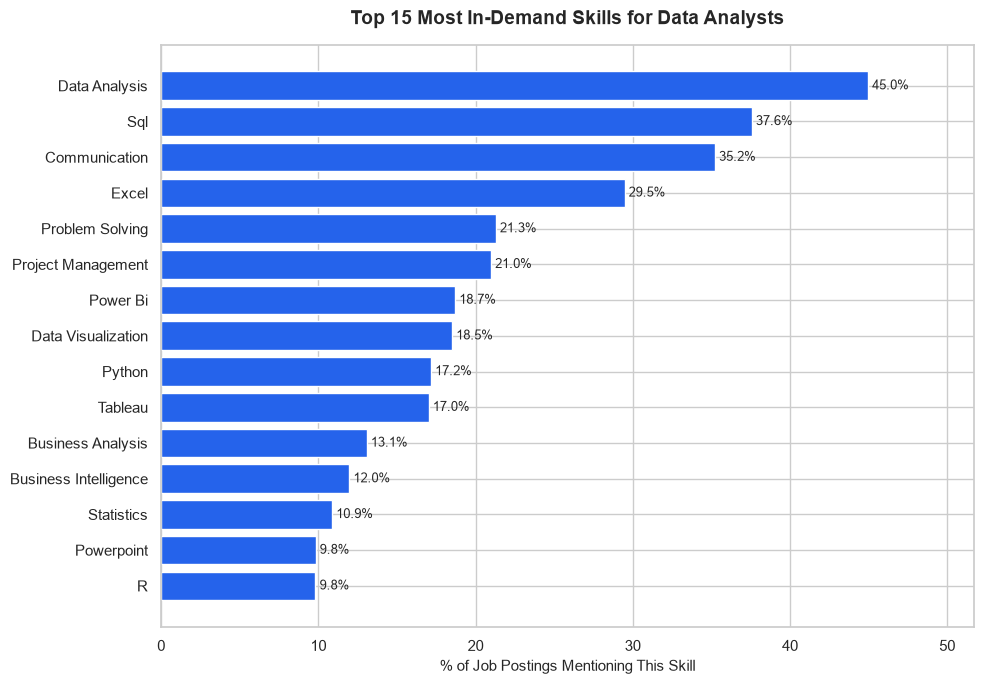

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent, clean style for all charts in this project
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# Get top 15 skills by prevalence (using our curated skill columns)
skill_cols = [c for c in df.columns if c.startswith('skill_')]
skill_pct = (df[skill_cols].mean() * 100).sort_values(ascending=False).head(15)
skill_pct.index = [c.replace('skill_', '').replace('_', ' ').title() for c in skill_pct.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(skill_pct.index[::-1], skill_pct.values[::-1], color='#2563EB')

ax.set_xlabel('% of Job Postings Mentioning This Skill', fontsize=11)
ax.set_title('Top 15 Most In-Demand Skills for Data Analysts', fontsize=14, fontweight='bold', pad=15)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlim(0, max(skill_pct.values) * 1.15)

plt.tight_layout()
plt.savefig('charts/chart1_top_skills.png', dpi=150, bbox_inches='tight')
plt.show()

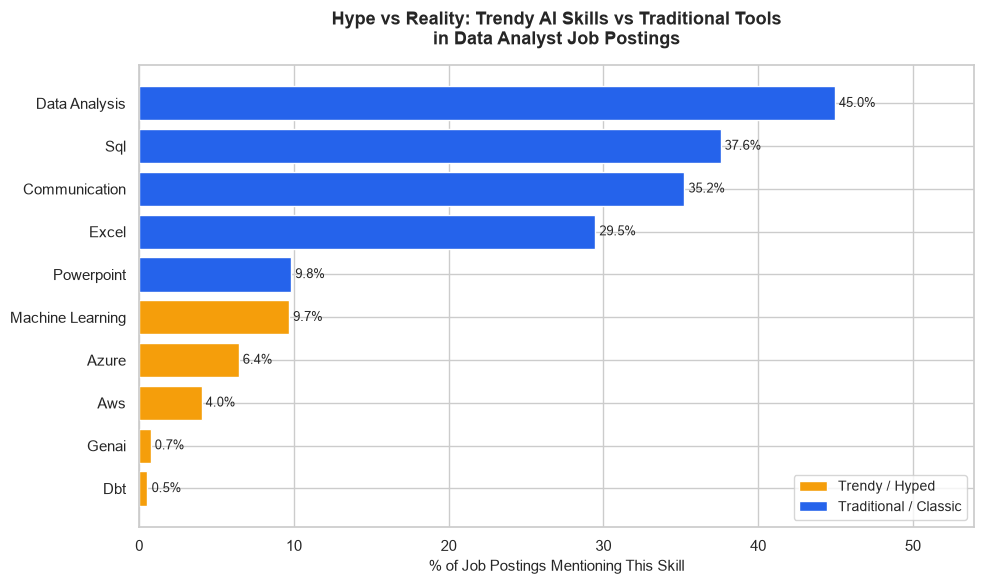

In [24]:
# Compare "trendy" skills vs "traditional" skills side by side
trendy_skills = ['skill_genai', 'skill_dbt', 'skill_machine_learning', 'skill_aws', 'skill_azure']
traditional_skills = ['skill_excel', 'skill_sql', 'skill_data_analysis', 'skill_communication', 'skill_powerpoint']

trendy_pct = (df[trendy_skills].mean() * 100)
traditional_pct = (df[traditional_skills].mean() * 100)

# Combine into one dataframe for plotting
comparison_data = pd.DataFrame({
    'skill': [s.replace('skill_', '').replace('_', ' ').title() for s in trendy_skills + traditional_skills],
    'pct': list(trendy_pct.values) + list(traditional_pct.values),
    'category': ['Trendy/Hyped'] * len(trendy_skills) + ['Traditional/Classic'] * len(traditional_skills)
})
comparison_data = comparison_data.sort_values('pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = comparison_data['category'].map({'Trendy/Hyped': '#F59E0B', 'Traditional/Classic': '#2563EB'})
bars = ax.barh(comparison_data['skill'], comparison_data['pct'], color=colors)

ax.set_xlabel('% of Job Postings Mentioning This Skill', fontsize=11)
ax.set_title('Hype vs Reality: Trendy AI Skills vs Traditional Tools\nin Data Analyst Job Postings', 
             fontsize=13, fontweight='bold', pad=15)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlim(0, max(comparison_data['pct']) * 1.2)

# Custom legend since we're using color to encode category
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F59E0B', label='Trendy / Hyped'),
                    Patch(facecolor='#2563EB', label='Traditional / Classic')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('chart2_trendy_vs_traditional.png', dpi=150, bbox_inches='tight')
plt.show()

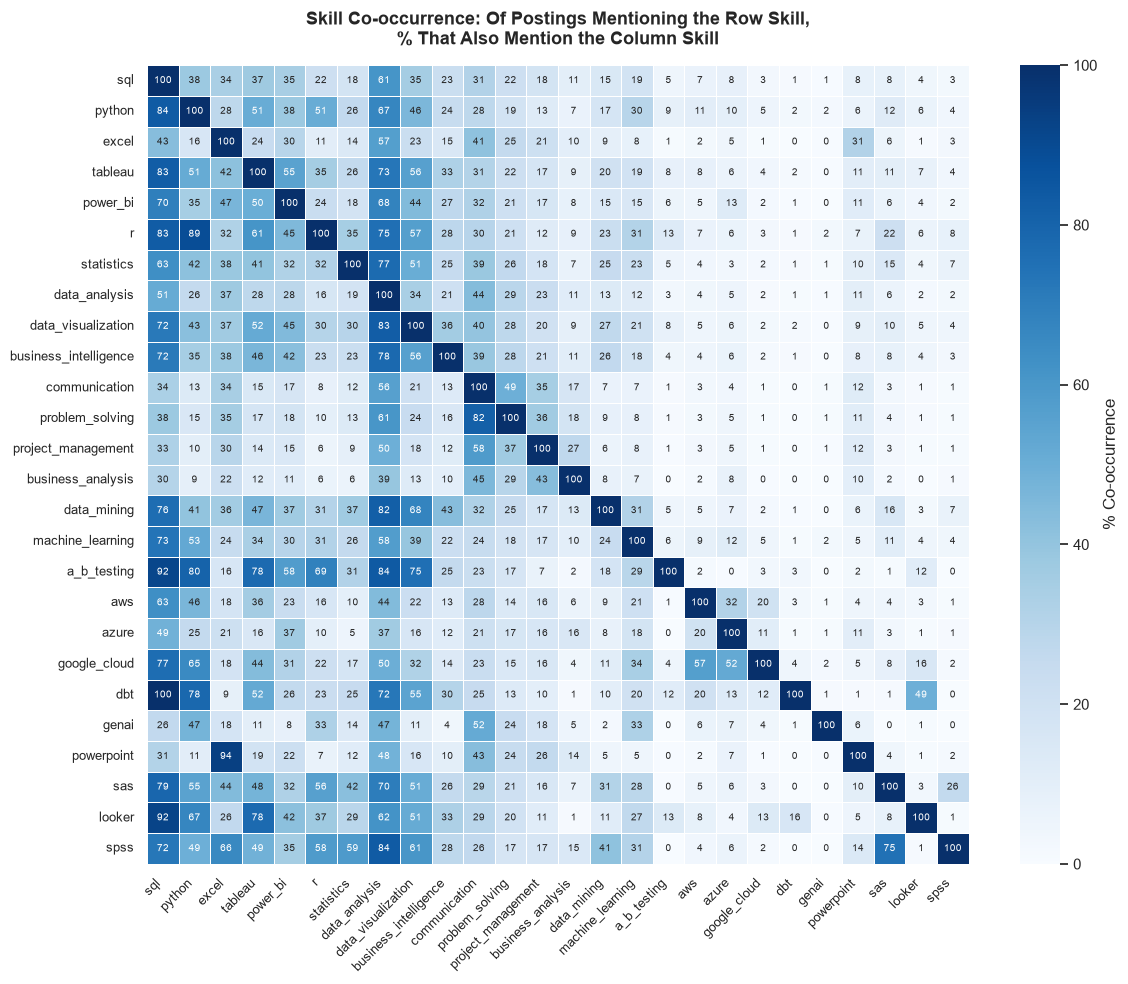

In [25]:
# Heatmap of skill co-occurrence (using the normalized % matrix from Step 4)
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    cooccurrence_pct, 
    annot=True, 
    fmt='.0f', 
    cmap='Blues', 
    cbar_kws={'label': '% Co-occurrence'},
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)

ax.set_title('Skill Co-occurrence: Of Postings Mentioning the Row Skill,\n% That Also Mention the Column Skill', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('chart3_skill_cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

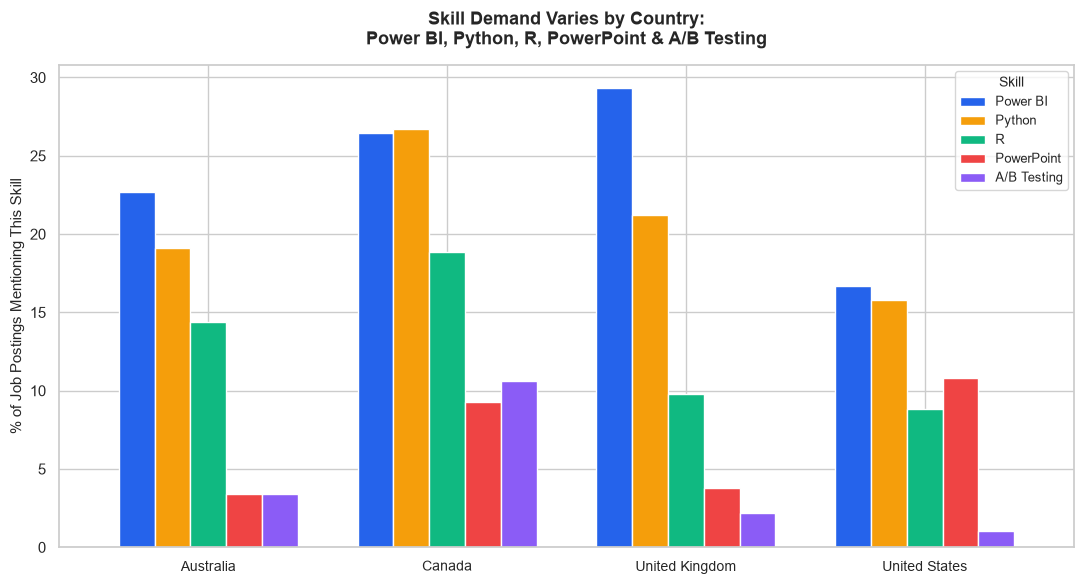

In [26]:
# Grouped bar chart showing the most country-differentiated skills
key_skills_by_country = ['power_bi', 'python', 'r', 'powerpoint', 'a_b_testing']
plot_data = skill_by_country.loc[key_skills_by_country]

fig, ax = plt.subplots(figsize=(11, 6))
plot_data.T.plot(kind='bar', ax=ax, width=0.75, 
                   color=['#2563EB', '#F59E0B', '#10B981', '#EF4444', '#8B5CF6'])

ax.set_ylabel('% of Job Postings Mentioning This Skill', fontsize=11)
ax.set_xlabel('')
ax.set_title('Skill Demand Varies by Country:\nPower BI, Python, R, PowerPoint & A/B Testing', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Skill', labels=['Power BI', 'Python', 'R', 'PowerPoint', 'A/B Testing'], 
          fontsize=9, title_fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('chart4_skills_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\A\AppData\Local\Temp\ipykernel_7848\1543767978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


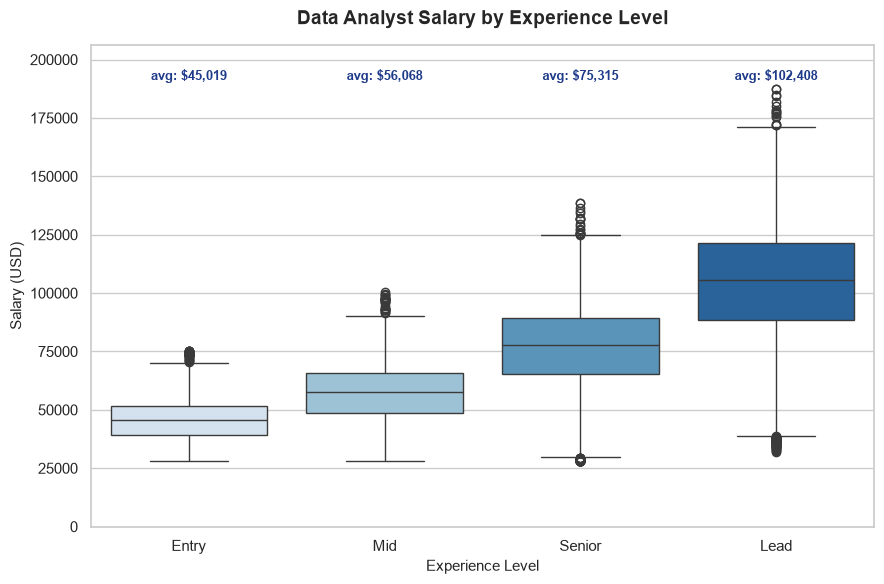

In [27]:
# Salary progression across experience levels (Data Analyst subset, df2_da)
exp_order = ['Entry', 'Mid', 'Senior', 'Lead']

fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=df2_da, 
    x='experience_level', 
    y='salary_usd', 
    order=exp_order,
    palette='Blues',
    ax=ax
)

ax.set_xlabel('Experience Level', fontsize=11)
ax.set_ylabel('Salary (USD)', fontsize=11)
ax.set_title('Data Analyst Salary by Experience Level', fontsize=14, fontweight='bold', pad=15)

# Add mean values as text annotations above each box
means = df2_da.groupby('experience_level')['salary_usd'].mean().reindex(exp_order)
for i, mean_val in enumerate(means):
    ax.text(i, df2_da['salary_usd'].max() * 1.02, f'avg: ${mean_val:,.0f}', 
            ha='center', fontsize=9, fontweight='bold', color='#1E3A8A')

ax.set_ylim(0, df2_da['salary_usd'].max() * 1.1)

plt.tight_layout()
plt.savefig('chart5_salary_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
plt.savefig('chart1_top_skills.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [29]:
plt.savefig('charts/chart1_top_skills.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [30]:
# Export the cleaned, skill-flagged dataframe for use in the Streamlit dashboard
df.to_csv('data/cleaned_postings.csv', index=False)
print("Exported cleaned dataset:", df.shape)

Exported cleaned dataset: (12894, 38)


In [32]:
df2_da.to_csv('data/salary_data_analyst.csv', index=False)
print("Exported salary subset:", df2_da.shape)

Exported salary subset: (11063, 35)
